# Givens QMC Results

In this notebook the Givens QMC results for BeH2 and N2 are plotted. 

For BeH2 we plot the median iteration at which a determinant appears (over 10 runs) as a boxplot and compare it to the average coefficient of the determinant in the final wavefunction.

For N2 we plot the median iteration at which a determinant is spawned to vs the average coefficient as a scatter plot.

Spearman correlation results are found in `Givens_results/Givens_QMC/correlation_tests.txt`

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

In [28]:
# Color Scheme
COLORS = {
    "H1-1": "#F24236",
    "H1-1E": "#0077B6",
    "H1-1_annotation": "#7D2528",
    "H1-1E_annotation": "#001f3f",
    "UCCSD": "#784c00",
    "UCCSD_annotation": "#291211",
    "Statevector": "#48C9B0",
    "HF_baseline": "#444444",
}
colors = ["#F24236", "#0077B6",  "#7D2528", "#001f3f", "#784c00", "#48C9B0"]

## BeH2

/var/folders/zf/d72094bj74d280n3l34ss62w0000gn/T/ipykernel_10798/843401487.py:25: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1b.set_xlim(max(np.log(np.abs(coeffs_sorted)+0.5)), min(np.log(np.abs(coeffs_sorted))))


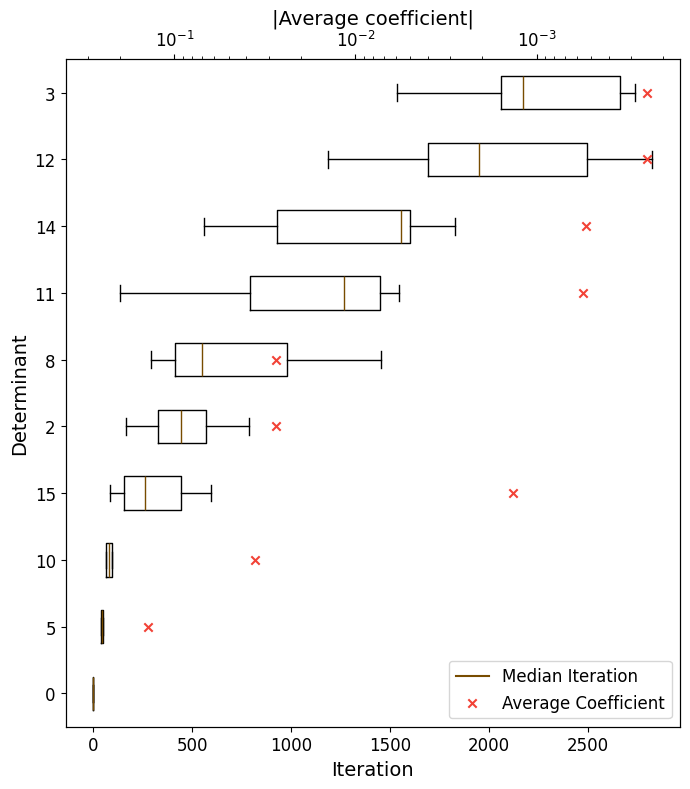

In [31]:
RESULTS_ROOT = Path("../Givens_results/Givens_QMC")
data = np.load(RESULTS_ROOT / "BeH2_correlation_data.npz", allow_pickle=True)
iters = data["iterations"]              # iterations at which each determinants is spawned to
det_labels = data["det_labels"]         # labels of determinants, sorted by iteration   
coeffs_sorted = data["coeffs_sorted"]   # average coefficients of determinants, sorted by iteration

fig, (ax1) = plt.subplots(1, 1, figsize=(7, 8), sharey=True)

# Boxplot of iterations for each determinant
bp = ax1.boxplot(list(iters), vert=False, tick_labels=det_labels, showfliers=False)
for median in bp['medians']:
    median.set_color(colors[4])
ax1.set_ylabel("Determinant", fontsize=14)
ax1.set_xlabel("Iteration", fontsize=14)
ax1.tick_params(axis='both', labelsize=12)

# Add coefficient scatter plot on top
ax1b = ax1.twiny()
ax1b.scatter(coeffs_sorted, range(1, len(det_labels) + 1),
             color=colors[0], marker="x", label="Average Coefficient")
ax1b.set_xlabel("|Average coefficient|", fontsize=14)
ax1b.tick_params(axis='x', labelsize=12)
ax1b.set_xscale("log")
plt.gca().invert_xaxis()
ax1b.set_xlim(max(np.log(np.abs(coeffs_sorted)+0.5)), min(np.log(np.abs(coeffs_sorted))))

# Legend
median_line = Line2D([0], [0], color=colors[4], label="Median Iteration")
handles, labels = ax1b.get_legend_handles_labels()
ax1.legend(handles=[median_line] + handles, loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

## N2

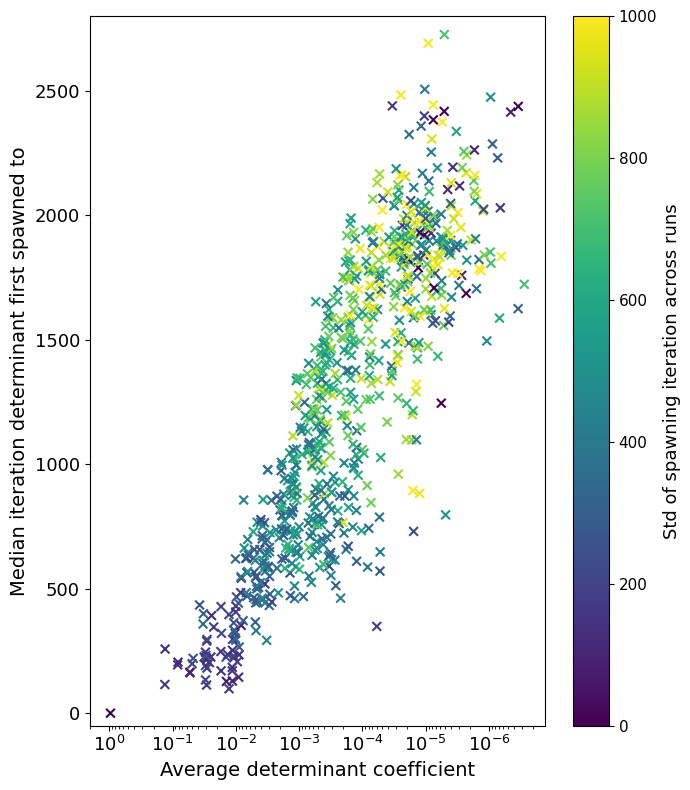

Range of medians: 4692
Median std:       531
Ratio (signal/noise): 8.8
Determinants beyond y=2800: 4 of 779
Range of visible medians: 2726
Visible signal/noise:     5.1


In [35]:
RESULTS_ROOT = Path("../Givens_results/Givens_QMC")
data = np.load(RESULTS_ROOT / "N2_correlation_data.npz", allow_pickle=True)
medians = data["medians"]
iter_sd = data["iter_stds"]
iters = data["iterations"]
coeffs_sorted = data["coeffs_sorted"]

fig, (ax1) = plt.subplots(1, 1, figsize=(7, 8), sharey=True)

sc = ax1.scatter(coeffs_sorted, medians,
                 c=iter_sd, cmap="viridis",
                 vmin=0, vmax=1000,
                 marker="x", s=40,
                 label="Average coefficient")

cbar = fig.colorbar(sc, ax=ax1)
cbar.set_label("Std of spawning iteration across runs", fontsize=13)
cbar.ax.tick_params(labelsize=11)
ax1.set_ylabel("Median iteration determinant first spawned to", fontsize=14)
ax1.set_xlabel("Average determinant coefficient", fontsize=14)
ax1.set_xscale("log")
ax1.set_ylim(-50, 2800)
ax1.tick_params(axis='both', labelsize=13)

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

print(f"Range of medians: {max(medians) - min(medians):.0f}")
print(f"Median std:       {np.median(iter_sd):.0f}")
print(f"Ratio (signal/noise): "
      f"{(max(medians) - min(medians)) / np.median(iter_sd):.1f}")

n_beyond = sum(1 for m in medians if m > 2800)
print(f"Determinants beyond y=2800: {n_beyond} of {len(medians)}")

# Range and ratio if we exclude them
visible_medians = [m for m in medians if m <= 2800]
print(f"Range of visible medians: {max(visible_medians) - min(visible_medians):.0f}")
print(f"Visible signal/noise:     {(max(visible_medians) - min(visible_medians)) / 531:.1f}")